<a href="https://colab.research.google.com/github/dkang1630/Conductor_Image_Classification/blob/main/CNN_Coductor_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
from torchsummary import summary


# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Set random seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Torch random tensor:", torch.rand(3))  # Generate a random tensor with 3 elements
print("Numpy random array:", np.random.rand(3))  # Generate a random array with 3 elements
print("Python random number:", random.random())  # Generate a random float

Torch random tensor: tensor([0.8823, 0.9150, 0.3829])
Numpy random array: [0.37454012 0.95071431 0.73199394]
Python random number: 0.6394267984578837


In [ ]:
#Image Transformations
IMG_SIZE = 128
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),               # Horizontal Flip (50% chance)
    transforms.RandomRotation(15),                        # Random Rotation (±15 degrees)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random Translation (10% shift)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Color Jitter
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), # Random Crop with Scaling
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])


In [ ]:
#Custom dataset class
class CustomDataset(Dataset):
  def __init__(self, base_path, classes, subfolders, transform=None):
    self.data = []
    self.labels = []
    self.transform = transform
    self.class_map = {class_name: idx for idx, class_name in enumerate(classes)}

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        if os.path.isdir(class_path):
            label = self.class_map[class_name]  # Assign label based on class
            for subfolder in subfolders:
                subfolder_path = os.path.join(class_path, subfolder)
                if os.path.isdir(subfolder_path):  # Check if subfolder exists
                    for img_name in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_name)
                        self.data.append(img_path)
                        self.labels.append(label)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img_path = self.data[idx]
    label = self.labels[idx]
    #image = Image.open(img_path).convert("L") #L for grayscale
    image = Image.open(img_path).convert("RGB") #Color

    if self.transform:
      image = self.transform(image)
    return image, label

def split_data(base_path, classes, subfolders, train_ratio=0.8, test_ratio=0.2, random_state=123):
    dataset = CustomDataset(base_path, classes, subfolders, transform=None)  # No transform for now
    images = dataset.data
    labels = dataset.labels

    # Split the data into train and test using the specified ratio
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=(1 - train_ratio), random_state=random_state, stratify=labels
    )

    return X_train, X_test, y_train, y_test


In [ ]:
# Paths
BASE_PATH = "/content/drive/My Drive/Colab Notebooks/Conductor_Image_Detection/Images/Lab_experiment/Classified"
ORIGINAL_PATH = os.path.join(BASE_PATH, "Original")
GVN_PATH = os.path.join(BASE_PATH, "GVN_Processed")
CLASSES = ["Healthy", "Minor_Corrosion", "Corrosion_Pollutant_Build_Up", "Fretting_Pollutant_Build_Up_Corrosion"]
SUBFOLDERS = ["from_auto", "from_D", "from_H", "from_W"]
SAVE_PATH = "/content/drive/My Drive/Colab Notebooks/MDR_Inspection/best_CNN_model.pth"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
# Initialize datasets with appropriate transforms
train_dataset_original = CustomDataset(ORIGINAL_PATH, CLASSES, SUBFOLDERS, transform=transform_train)
test_dataset_original = CustomDataset(ORIGINAL_PATH, CLASSES, SUBFOLDERS, transform=transform_val)
train_dataset_gvn = CustomDataset(GVN_PATH, CLASSES, SUBFOLDERS, transform=transform_train)
test_dataset_gvn = CustomDataset(GVN_PATH, CLASSES, SUBFOLDERS, transform=transform_val)

# Split datasets into training and testing sets
X_train_original, X_test_original, y_train_original, y_test_original = split_data(
    ORIGINAL_PATH, CLASSES, SUBFOLDERS, train_ratio=0.8, test_ratio=0.2
)
X_train_gvn, X_test_gvn, y_train_gvn, y_test_gvn = split_data(
    GVN_PATH, CLASSES, SUBFOLDERS, train_ratio=0.8, test_ratio=0.2
)

# Function to print class distribution
def print_class_distribution(y_data, classes):
    distribution = np.bincount(y_data, minlength=len(classes))
    for i, count in enumerate(distribution):
        print(f"Class '{classes[i]}': {count}")

# Display the distributions for Original Dataset
print(f"Original Training data size: {len(X_train_original)}")
print(f"Original Test data size: {len(X_test_original)}")
print("\nOriginal Training labels distribution:")
print_class_distribution(y_train_original, CLASSES)
print("\nOriginal Test labels distribution:")
print_class_distribution(y_test_original, CLASSES)

# Display the distributions for GVN Dataset
print(f"\nGVN Training data size: {len(X_train_gvn)}")
print(f"GVN Test data size: {len(X_test_gvn)}")
print("\nGVN Training labels distribution:")
print_class_distribution(y_train_gvn, CLASSES)
print("\nGVN Test labels distribution:")
print_class_distribution(y_test_gvn, CLASSES)

# Convert split data into torch datasets using indices for Original Dataset
train_indices_original = [train_dataset_original.data.index(path) for path in X_train_original]
test_indices_original = [test_dataset_original.data.index(path) for path in X_test_original]

train_dataset_original = Subset(train_dataset_original, train_indices_original)
test_dataset_original = Subset(test_dataset_original, test_indices_original)

# Convert split data into torch datasets using indices for GVN Dataset
train_indices_gvn = [train_dataset_gvn.data.index(path) for path in X_train_gvn]
test_indices_gvn = [test_dataset_gvn.data.index(path) for path in X_test_gvn]

train_dataset_gvn = Subset(train_dataset_gvn, train_indices_gvn)
test_dataset_gvn = Subset(test_dataset_gvn, test_indices_gvn)

# DataLoader for training and testing Original Dataset
train_loader_original = DataLoader(train_dataset_original, batch_size=32, shuffle=True)
test_loader_original = DataLoader(test_dataset_original, batch_size=32, shuffle=False)

# DataLoader for training and testing GVN Dataset
train_loader_gvn = DataLoader(train_dataset_gvn, batch_size=32, shuffle=True)
test_loader_gvn = DataLoader(test_dataset_gvn, batch_size=32, shuffle=False)

Original Training data size: 3780
Original Test data size: 945

Original Training labels distribution:
Class 'Healthy': 1151
Class 'Minor_Corrosion': 234
Class 'Corrosion_Pollutant_Build_Up': 1211
Class 'Fretting_Pollutant_Build_Up_Corrosion': 1184

Original Test labels distribution:
Class 'Healthy': 287
Class 'Minor_Corrosion': 59
Class 'Corrosion_Pollutant_Build_Up': 303
Class 'Fretting_Pollutant_Build_Up_Corrosion': 296

GVN Training data size: 1672
GVN Test data size: 418

GVN Training labels distribution:
Class 'Healthy': 125
Class 'Minor_Corrosion': 222
Class 'Corrosion_Pollutant_Build_Up': 847
Class 'Fretting_Pollutant_Build_Up_Corrosion': 478

GVN Test labels distribution:
Class 'Healthy': 31
Class 'Minor_Corrosion': 56
Class 'Corrosion_Pollutant_Build_Up': 212
Class 'Fretting_Pollutant_Build_Up_Corrosion': 119


In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            # Convolutional Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.3),

            # Convolutional Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.3),

            # Convolutional Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.4),

            # Convolutional Block 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.4)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(256 * 8 * 8, 1024),  # Adjust input size based on image dimensions
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [ ]:
def train_evaluate_customcnn_model(model, train_loader, val_loader, device,
                                   epochs=15, patience=5, lr=0.0003, save_path=SAVE_PATH):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    #ReduceLROnPlateau scheduler: reduced lr when metric stops improving
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Dictionary to store training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'total_time': None  # To store total compute time for training
    }

    # Record overall training start time
    train_start_time = time.time()

    print("\nStarting Integrated Training & Evaluation...\n" + "="*50)
    for epoch in range(epochs):
        epoch_start_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        total_train_samples = 0

        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_train_corrects += torch.sum(preds == labels).item()
            total_train_samples += labels.size(0)

            if batch_idx % 10 == 0 or batch_idx == len(train_loader):
                print(f"[Train] Batch {batch_idx}/{len(train_loader)} processed.")

        train_loss = running_train_loss / total_train_samples
        train_accuracy = running_train_corrects / total_train_samples * 100
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_accuracy)
        print(f"Training Loss: {train_loss:.6f}, Training Accuracy: {train_accuracy:.2f}%")

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        total_val_samples = 0
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for batch_idx, (images, labels) in enumerate(val_loader, start=1):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                running_val_corrects += torch.sum(preds == labels).item()
                total_val_samples += labels.size(0)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

                if batch_idx % 10 == 0 or batch_idx == len(val_loader):
                    print(f"[Validation] Batch {batch_idx}/{len(val_loader)} processed.")

        val_loss = running_val_loss / total_val_samples
        val_accuracy = running_val_corrects / total_val_samples * 100
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_accuracy)

        # Compute loss gap between validation and training loss
        loss_gap = (val_loss - train_loss) / train_loss
        epoch_time = time.time() - epoch_start_time

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  - Time elapsed: {epoch_time:.2f} sec")
        print(f"  - Train Loss: {train_loss:.6f}, Train Acc: {train_accuracy:.2f}%")
        print(f"  - Val Loss: {val_loss:.6f}, Val Acc: {val_accuracy:.2f}%")
        print(f"  - Loss Gap (Val-Train)/Train: {loss_gap*100:.2f}%")

        # Save model if validation loss improves
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print("  -> Validation loss improved; model saved!")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
            if epochs_no_improve >= patience:
                print("  -> Early stopping triggered!")
                break

        scheduler.step(val_loss)

        #display confusion matrix for the epoch
        conf_matrix = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
        disp.plot(cmap='Blues')
        plt.title(f"Epoch {epoch+1} Confusion Matrix")
        plt.show()

    # Compute total training time
    total_training_time = time.time() - train_start_time
    history['total_time'] = total_training_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")

    # Load the best model before returning
    model.load_state_dict(torch.load(save_path))
    print("\nBest model loaded for final evaluation.")
    return model, history


In [ ]:
model = CustomCNN(num_classes=4).to('cuda' if torch.cuda.is_available() else 'cpu')
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
           Dropout-5           [-1, 32, 64, 64]               0
            Conv2d-6           [-1, 64, 64, 64]          18,496
       BatchNorm2d-7           [-1, 64, 64, 64]             128
              ReLU-8           [-1, 64, 64, 64]               0
         MaxPool2d-9           [-1, 64, 32, 32]               0
          Dropout-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 128, 32, 32]          73,856
      BatchNorm2d-12          [-1, 128, 32, 32]             256
             ReLU-13          [-1, 128, 32, 32]               0
        MaxPool2d-14          [-1, 128,


Starting Integrated Training & Evaluation...

--- Epoch 1/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.925110, Training Accuracy: 58.02%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 1 Summary:
  - Time elapsed: 33.48 sec
  - Train Loss: 0.925110, Train Acc: 58.02%
  - Val Loss: 0.887432, Val Acc: 55.34%
  - Loss Gap (Val-Train)/Train: -4.07%
  -> Validation loss improved; model saved!


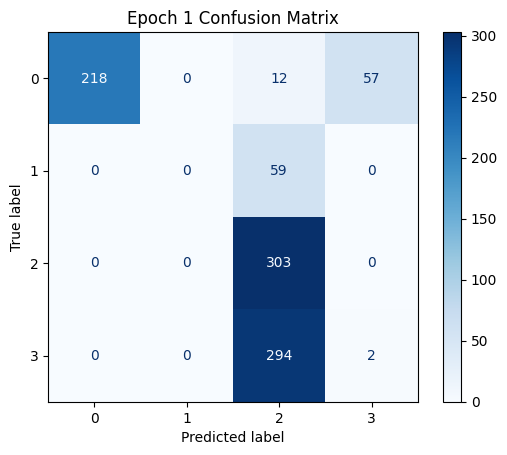


--- Epoch 2/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.714063, Training Accuracy: 66.53%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 2 Summary:
  - Time elapsed: 33.49 sec
  - Train Loss: 0.714063, Train Acc: 66.53%
  - Val Loss: 0.671439, Val Acc: 63.49%
  - Loss Gap (Val-Train)/Train: -5.97%
  -> Validation loss improved; model saved!


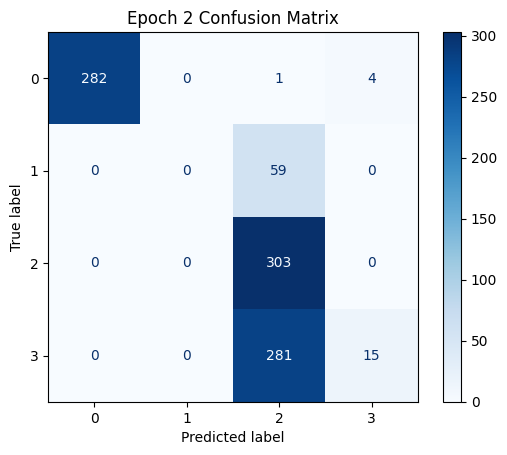


--- Epoch 3/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.636444, Training Accuracy: 71.38%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 3 Summary:
  - Time elapsed: 33.81 sec
  - Train Loss: 0.636444, Train Acc: 71.38%
  - Val Loss: 0.666076, Val Acc: 67.30%
  - Loss Gap (Val-Train)/Train: 4.66%
  -> Validation loss improved; model saved!


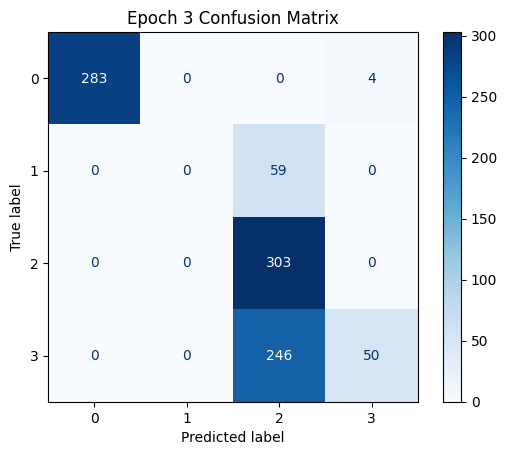


--- Epoch 4/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.604638, Training Accuracy: 74.76%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 4 Summary:
  - Time elapsed: 33.60 sec
  - Train Loss: 0.604638, Train Acc: 74.76%
  - Val Loss: 0.547163, Val Acc: 75.98%
  - Loss Gap (Val-Train)/Train: -9.51%
  -> Validation loss improved; model saved!


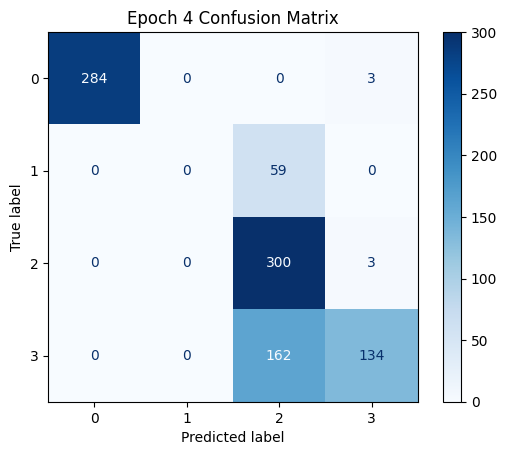


--- Epoch 5/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.585712, Training Accuracy: 74.79%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 5 Summary:
  - Time elapsed: 33.50 sec
  - Train Loss: 0.585712, Train Acc: 74.79%
  - Val Loss: 0.535873, Val Acc: 78.73%
  - Loss Gap (Val-Train)/Train: -8.51%
  -> Validation loss improved; model saved!


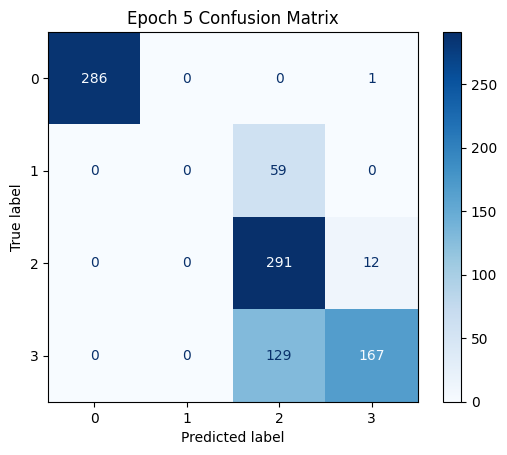


--- Epoch 6/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.563094, Training Accuracy: 76.14%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 6 Summary:
  - Time elapsed: 33.44 sec
  - Train Loss: 0.563094, Train Acc: 76.14%
  - Val Loss: 0.475682, Val Acc: 79.79%
  - Loss Gap (Val-Train)/Train: -15.52%
  -> Validation loss improved; model saved!


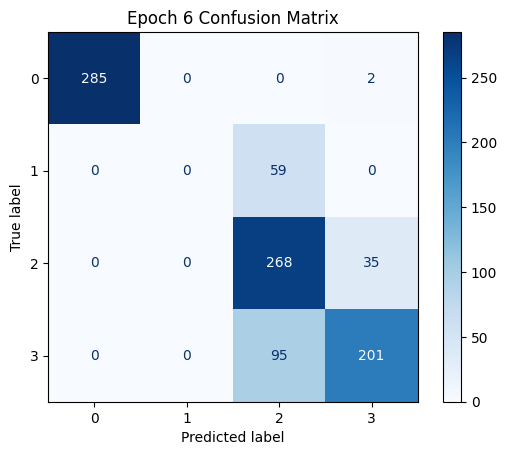


--- Epoch 7/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.617916, Training Accuracy: 74.34%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 7 Summary:
  - Time elapsed: 33.64 sec
  - Train Loss: 0.617916, Train Acc: 74.34%
  - Val Loss: 0.478686, Val Acc: 80.53%
  - Loss Gap (Val-Train)/Train: -22.53%
  -> No improvement for 1 epoch(s).


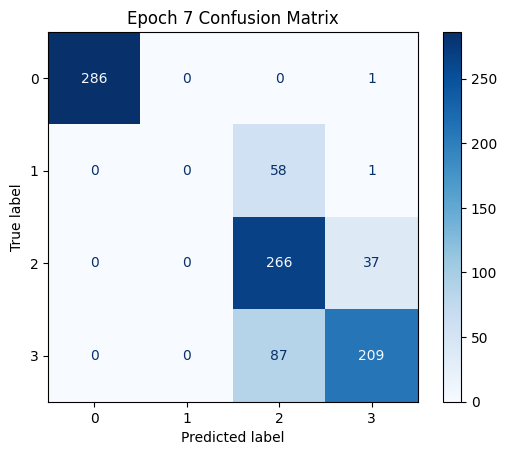


--- Epoch 8/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.542448, Training Accuracy: 77.09%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 8 Summary:
  - Time elapsed: 33.41 sec
  - Train Loss: 0.542448, Train Acc: 77.09%
  - Val Loss: 0.470640, Val Acc: 81.38%
  - Loss Gap (Val-Train)/Train: -13.24%
  -> Validation loss improved; model saved!


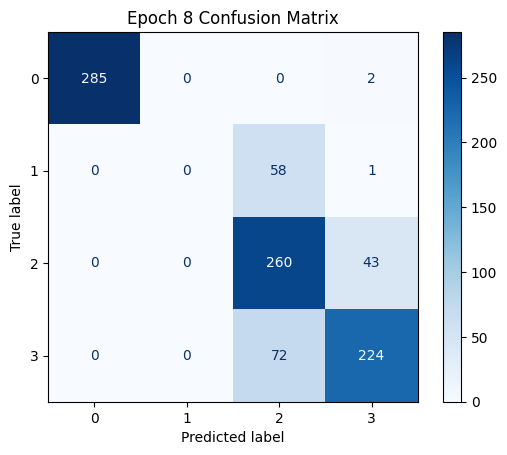


--- Epoch 9/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.537721, Training Accuracy: 77.43%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 9 Summary:
  - Time elapsed: 33.30 sec
  - Train Loss: 0.537721, Train Acc: 77.43%
  - Val Loss: 0.474026, Val Acc: 81.06%
  - Loss Gap (Val-Train)/Train: -11.85%
  -> No improvement for 1 epoch(s).


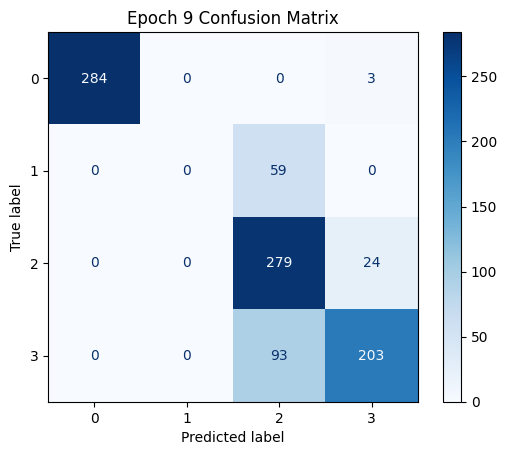


--- Epoch 10/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.539351, Training Accuracy: 77.83%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 10 Summary:
  - Time elapsed: 33.36 sec
  - Train Loss: 0.539351, Train Acc: 77.83%
  - Val Loss: 0.484953, Val Acc: 80.42%
  - Loss Gap (Val-Train)/Train: -10.09%
  -> No improvement for 2 epoch(s).


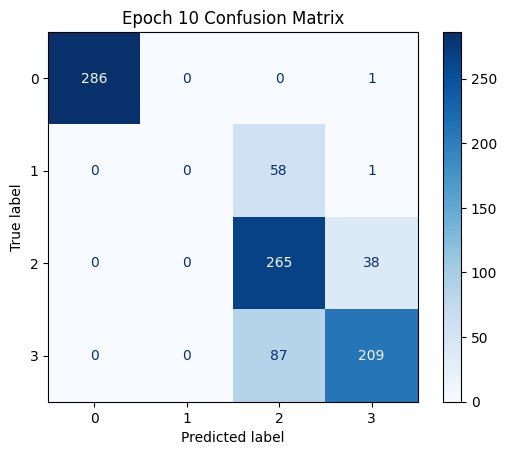


--- Epoch 11/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.533979, Training Accuracy: 77.88%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 11 Summary:
  - Time elapsed: 33.47 sec
  - Train Loss: 0.533979, Train Acc: 77.88%
  - Val Loss: 0.461053, Val Acc: 81.38%
  - Loss Gap (Val-Train)/Train: -13.66%
  -> Validation loss improved; model saved!


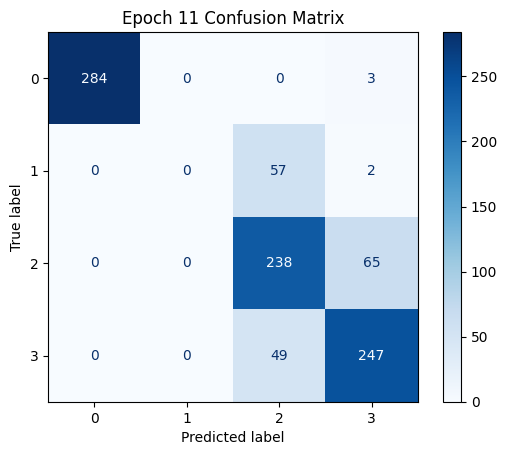


--- Epoch 12/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.525432, Training Accuracy: 77.88%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 12 Summary:
  - Time elapsed: 33.79 sec
  - Train Loss: 0.525432, Train Acc: 77.88%
  - Val Loss: 0.450197, Val Acc: 80.74%
  - Loss Gap (Val-Train)/Train: -14.32%
  -> Validation loss improved; model saved!


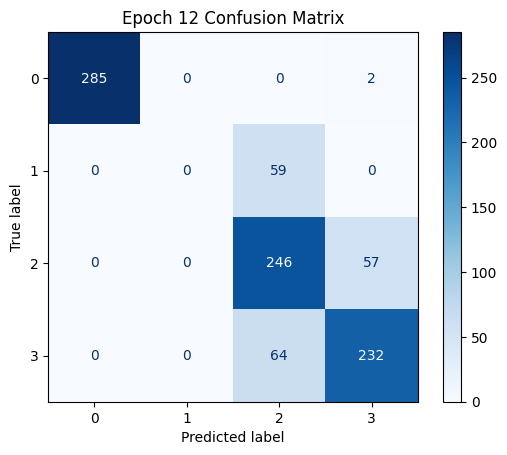


--- Epoch 13/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.514983, Training Accuracy: 78.47%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 13 Summary:
  - Time elapsed: 33.67 sec
  - Train Loss: 0.514983, Train Acc: 78.47%
  - Val Loss: 0.464144, Val Acc: 81.16%
  - Loss Gap (Val-Train)/Train: -9.87%
  -> No improvement for 1 epoch(s).


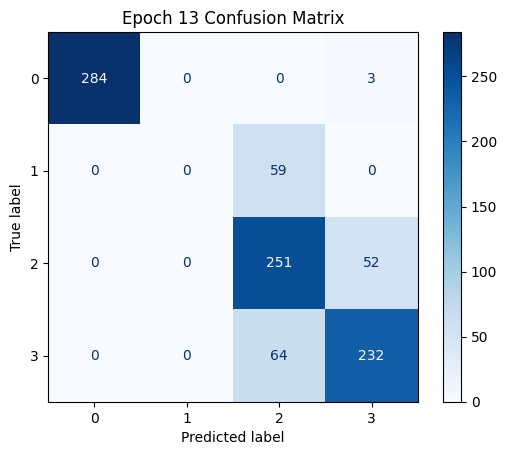


--- Epoch 14/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.530602, Training Accuracy: 78.31%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 14 Summary:
  - Time elapsed: 33.33 sec
  - Train Loss: 0.530602, Train Acc: 78.31%
  - Val Loss: 0.445565, Val Acc: 82.12%
  - Loss Gap (Val-Train)/Train: -16.03%
  -> Validation loss improved; model saved!


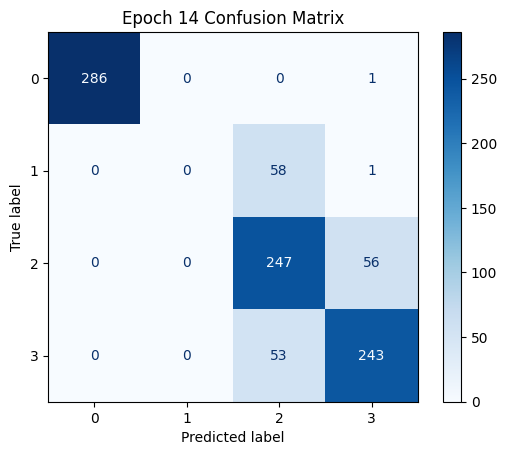


--- Epoch 15/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.528496, Training Accuracy: 77.99%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 15 Summary:
  - Time elapsed: 33.67 sec
  - Train Loss: 0.528496, Train Acc: 77.99%
  - Val Loss: 0.447881, Val Acc: 81.48%
  - Loss Gap (Val-Train)/Train: -15.25%
  -> No improvement for 1 epoch(s).


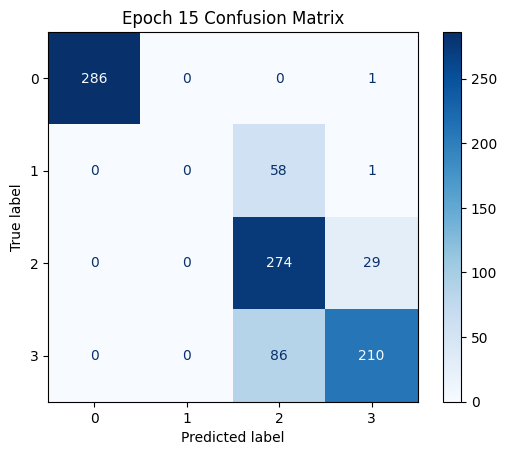


--- Epoch 16/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.533841, Training Accuracy: 77.96%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 16 Summary:
  - Time elapsed: 33.44 sec
  - Train Loss: 0.533841, Train Acc: 77.96%
  - Val Loss: 0.434235, Val Acc: 82.12%
  - Loss Gap (Val-Train)/Train: -18.66%
  -> Validation loss improved; model saved!


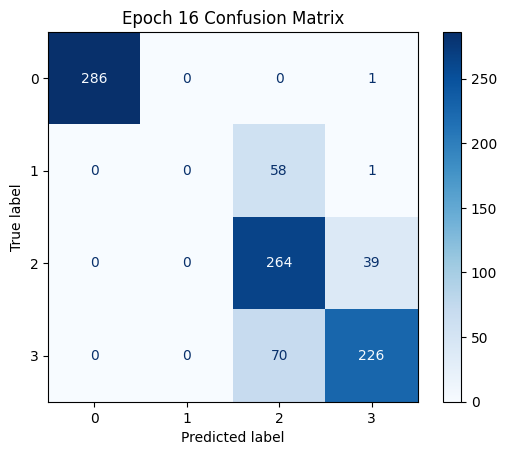


--- Epoch 17/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.524716, Training Accuracy: 78.54%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 17 Summary:
  - Time elapsed: 34.02 sec
  - Train Loss: 0.524716, Train Acc: 78.54%
  - Val Loss: 0.467508, Val Acc: 80.95%
  - Loss Gap (Val-Train)/Train: -10.90%
  -> No improvement for 1 epoch(s).


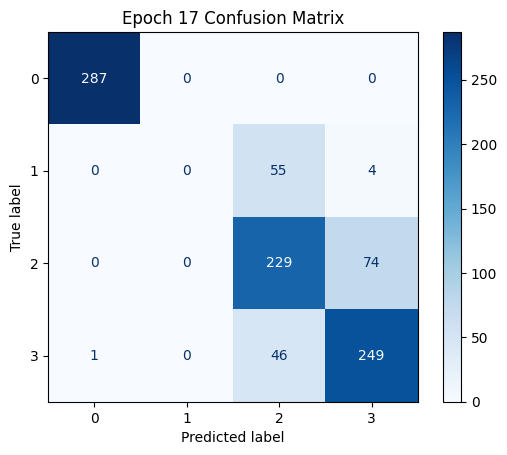


--- Epoch 18/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.553942, Training Accuracy: 76.85%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 18 Summary:
  - Time elapsed: 33.50 sec
  - Train Loss: 0.553942, Train Acc: 76.85%
  - Val Loss: 0.454905, Val Acc: 80.74%
  - Loss Gap (Val-Train)/Train: -17.88%
  -> No improvement for 2 epoch(s).


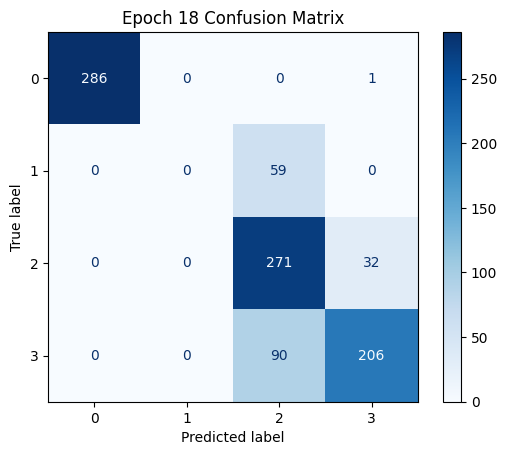


--- Epoch 19/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.535251, Training Accuracy: 78.15%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 19 Summary:
  - Time elapsed: 33.42 sec
  - Train Loss: 0.535251, Train Acc: 78.15%
  - Val Loss: 0.477925, Val Acc: 78.62%
  - Loss Gap (Val-Train)/Train: -10.71%
  -> No improvement for 3 epoch(s).


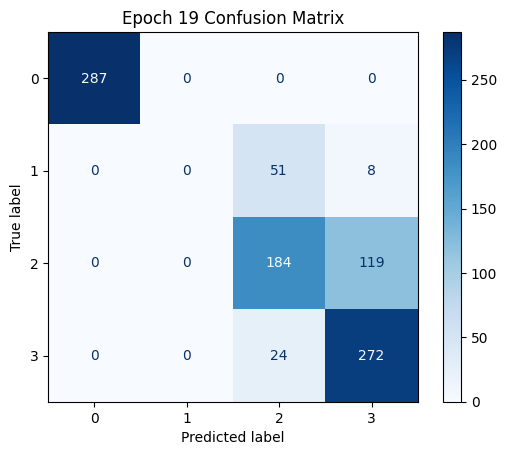


--- Epoch 20/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.511632, Training Accuracy: 79.10%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 20 Summary:
  - Time elapsed: 33.42 sec
  - Train Loss: 0.511632, Train Acc: 79.10%
  - Val Loss: 0.456441, Val Acc: 82.12%
  - Loss Gap (Val-Train)/Train: -10.79%
  -> No improvement for 4 epoch(s).


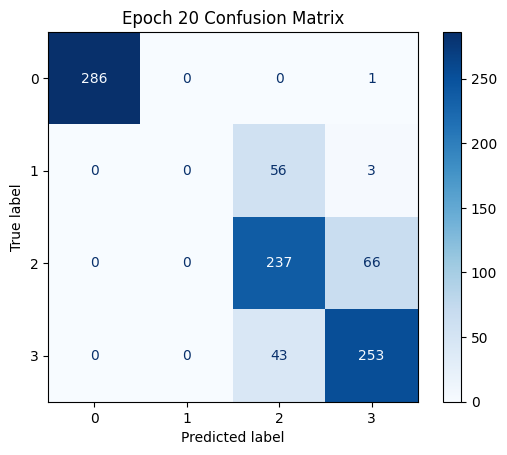


--- Epoch 21/50 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.488406, Training Accuracy: 79.55%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 21 Summary:
  - Time elapsed: 33.85 sec
  - Train Loss: 0.488406, Train Acc: 79.55%
  - Val Loss: 0.452647, Val Acc: 82.12%
  - Loss Gap (Val-Train)/Train: -7.32%
  -> No improvement for 5 epoch(s).
  -> Early stopping triggered!

Total Training Time: 710.15 seconds

Best model loaded for final evaluation.


<ipython-input-11-8f8f26e4f949>:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


In [ ]:
# --- Integrated Training & Evaluation Execution ---
trained_model, history = train_evaluate_customcnn_model(
    CustomCNN(),
    train_loader_original,
    test_loader_original,
    device,
    epochs=50,
    patience=5,
    lr=0.0003,
    save_path=SAVE_PATH
)

<ipython-input-12-0f8d4ca71ca3>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
Final Evaluation: 


Validation Loss: 0.4342
Validation Accuracy: 82.12%
Validation Precision (weighted): 0.7848
Validation Recall (weighted): 0.8212
Validation F1 Score (weighted): 0.7982


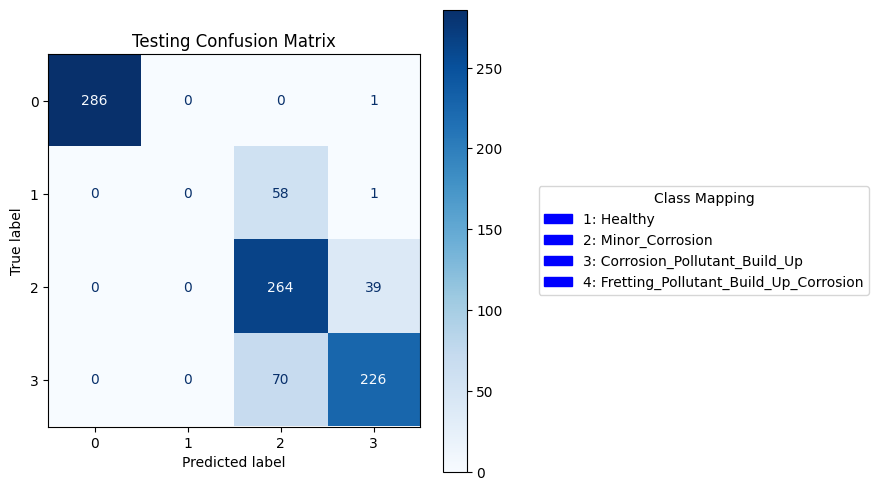

NameError: name 'history' is not defined

In [ ]:
trained_model = CustomCNN()
trained_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

# Final Evaluation on val_loader_original (or test_loader_original)
trained_model.to(device)
trained_model.eval()

total_val_samples = 0
running_val_loss = 0.0
all_labels = []
all_preds = []
criterion = nn.CrossEntropyLoss() # Define loss function

with torch.no_grad():
    for images, labels in tqdm(test_loader_original, desc="Final Evaluation"):
        images, labels = images.to(device), labels.to(device)
        outputs = trained_model(images)
        loss = criterion(outputs, labels) # Calculate loss for the batch
        running_val_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        total_val_samples += labels.size(0)

avg_loss = running_val_loss / total_val_samples

# Compute additional metrics using sklearn
val_accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

mode = "Validation"
print(f'\n{mode} Loss: {avg_loss:.4f}')
print(f'{mode} Accuracy: {val_accuracy:.2f}%')
print(f'{mode} Precision (weighted): {precision:.4f}')
print(f'{mode} Recall (weighted): {recall:.4f}')
print(f'{mode} F1 Score (weighted): {f1:.4f}')

# First, compute the confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# Create the confusion matrix display
fig, ax = plt.subplots(figsize=(6, 6))  # Adjust figure size if needed
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues', ax=ax)

# Create legend patches
legend_patches = [mpatches.Patch(color='blue', label=f"{i+1}: {name}") for i, name in enumerate(CLASSES)]

# Place the legend outside the plot on the right
plt.legend(handles=legend_patches, title="Class Mapping", loc="center left", bbox_to_anchor=(1.3, 0.5))

# Set title
plt.title("Testing Confusion Matrix")
plt.show()

# --- Plot combined Training & Validation Loss and Accuracy curves ---
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot Loss curves (primary y-axis)
line1, = ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', linestyle='--')
line2, = ax1.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create secondary y-axis for Accuracy
ax2 = ax1.twinx()
line3, = ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='red', linestyle='--')
line4, = ax2.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red')
ax2.set_ylabel('Accuracy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.title("Training & Validation Loss and Accuracy")
plt.tight_layout()
plt.show()

# Optionally, print total training time metric
print(f"Total training compute time: {history['total_time']:.2f} seconds")


In [ ]:
!apt-get install -y pandoc texlive texlive-xetex texlive-latex-extra


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-latex-extra is already the newest version (2021.20220204-1).
texlive-latex-extra set to manually installed.
texlive-xetex is already the newest version (2021.20220204-1).
The following additional packages will be installed:
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3 pandoc-data
Suggested packages:
  texlive-luatex pandoc-citeproc context wkhtmltopdf librsvg2-bin groff ghc nodejs php python
  libjs-mathjax libjs-katex citation-style-language-styles
The following NEW packages will be installed:
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3 pandoc pandoc-data texlive
0 upgraded, 5 newly installed, 0 to remove and 29 not upgraded.
Need to get 20.6 MB of archives.
After this operation, 156 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcmark-gfm0.29.0.gfm.3 amd64 0.29.0.gfm.3-3 [115 kB]
Get:2 h

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/MDR_Inspection/


/content/drive/.shortcut-targets-by-id/1CBsm-qkB1TuGqZoU-TjX6mM-QIJe2gcr/MDR_Inspection


In [ ]:
!jupyter nbconvert --to PDF "CNN_Coductor_Classification_Model.ipynb"

[NbConvertApp] Converting notebook CNN_Coductor_Classification_Model.ipynb to PDF
[NbConvertApp] Support files will be in CNN_Coductor_Classification_Model_files/
[NbConvertApp] Making directory ./CNN_Coductor_Classification_Model_files
[NbConvertApp] Writing 119469 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 560095 bytes to CNN_Coductor_Classification_Model.pdf
